# Federated RAG

To implements an improved FedRAG (Federated Retrieval-Augmented Generation) pipeline featuring:  

- Document chunking for fine-grained embeddings.  
- Embedding model selection.  
- Composite retrieval using LangChain.   

The goal is to enhance retrieval accuracy beside reducing hallucinations in Question Answering Chatbot tasks.

In [ ]:
# Install required packages
!pip install -qqq langchain faiss-cpu python-dotenv
!pip install -qqq -U langchain-openai
!pip install -qqq langchain-core langchain-openai langchain-community beautifulsoup4 requests
!pip install -qqq sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.2/65.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.1/438.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 988.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.

In [ ]:
import os
import sys
from bs4 import BeautifulSoup
import string
import requests
from urllib.parse import urljoin, urlparse
from langchain.document_loaders import WebBaseLoader
from langchain.text_splitter import CharacterTextSplitter
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain.docstore.document import Document
from langchain.chains import RetrievalQA
from langchain.retrievers import MergerRetriever
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util

In [ ]:
# Set OpenAI API key
os.environ["OPENAI_API_KEY"] = "sk-xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"

In [ ]:
def clean_html(raw_html: str) -> str:
    # Text cleaning (Remove boilerplate HTML tags like script, style, nav, footer, header)
    soup = BeautifulSoup(raw_html, "html.parser")
    for tag in soup(["script", "style", "nav", "footer", "header"]):
        tag.decompose()
    text = soup.get_text(separator="\n")
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    return "\n".join(lines)

def chunk_documents(docs, chunk_size=1100, chunk_overlap=200):
    #Split each LangChain Document into smaller chunks for embeddings.
    splitter = CharacterTextSplitter(
        separator="\n",
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )
    chunks = []
    for doc in docs:
        # Split page_contents
        pieces = splitter.split_text(doc.page_content)
        for piece in pieces:
            chunks.append(Document(page_content=piece, metadata=doc.metadata))
    return chunks

In [ ]:
#Web scraper that supports recursive crawling with depth control.

def scrape_website(url, max_depth=2):
    visited = set()
    documents = []
    domain = urlparse(url).netloc

    def scrape(current_url, depth):
        if depth > max_depth or current_url in visited:
            return

        visited.add(current_url)
        print(f"Scraping (depth {depth}): {current_url}", file=sys.stderr)

        try:
            # Use a realistic user agent
            headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
            response = requests.get(current_url, timeout=10, headers=headers)
            response.encoding = response.apparent_encoding  # Fix encoding issues
            response.raise_for_status()

            content = clean_html(response.text) # Clean HTML

            # Create document with metadata
            doc = Document(
                page_content=content,
                metadata={"source": current_url, "title": current_url.split("/")[-1]}
            )
            documents.append(doc)

            # Only follow links if not at max depth
            if depth < max_depth:
                soup = BeautifulSoup(response.text, "html.parser")
                for link in soup.find_all("a", href=True):
                    href = link["href"]
                    full_url = urljoin(current_url, href)

                    # Only follow links within the same domain
                    if urlparse(full_url).netloc == domain and full_url not in visited:
                        scrape(full_url, depth + 1)

        except Exception as e:
            print(f"Error scraping {current_url}: {e}", file=sys.stderr)

    # Start scraping from the initial URL
    scrape(url, 0)
    print(f"Scraped {len(documents)} pages from {url}", file=sys.stderr)
    return documents

def get_federated_docs(urls, max_depth=2):
    """
    Crawl a list of URLs up to max_depth and return a list of LangChain Document objects.
    """
    all_docs = []
    for url in urls:
        docs = scrape_website(url, max_depth=max_depth)
        all_docs.extend(docs)
    return all_docs

In [ ]:
# Initialize embedding model
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# Define URLs for Hull and Keele
hull_urls = [
    "https://online.hull.ac.uk",
    "https://online.hull.ac.uk/contact",
    "https://online.hull.ac.uk/why-join-us/faqs",
    "https://online.hull.ac.uk/funding-options",
    "https://online.hull.ac.uk/course-costs"
]

keele_urls = [
    "https://online.keele.ac.uk/online-programme/msc-computer-science-with-artificial-intelligence",
    "https://online.keele.ac.uk/online-study",
    "https://online.keele.ac.uk/about-us"
]

# Load, clean, and chunk documents
print("Loading and processing Hull documents...")
hull_raw = get_federated_docs(hull_urls, max_depth=1)
hull_chunks = chunk_documents(hull_raw)
print(f" - {len(hull_chunks)} Hull chunks created.")

print("Loading and processing Keele documents...")
keele_raw = get_federated_docs(keele_urls, max_depth=1)
keele_chunks = chunk_documents(keele_raw)
print(f" - {len(keele_chunks)} Keele chunks created.")

# Build FAISS indexes
print("Building FAISS index for Hull...")
hull_index = FAISS.from_documents(hull_chunks, embeddings)
print("Building FAISS index for Keele...")
keele_index = FAISS.from_documents(keele_chunks, embeddings)

Loading and processing Hull documents...


Scraping (depth 0): https://online.hull.ac.uk
Scraping (depth 1): https://online.hull.ac.uk/#main
Scraping (depth 1): https://online.hull.ac.uk/contact
Scraping (depth 1): https://online.hull.ac.uk/
Scraping (depth 1): https://online.hull.ac.uk/why-join-us/how-you-learn
Scraping (depth 1): https://online.hull.ac.uk/why-join-us/online-student-experience
Scraping (depth 1): https://online.hull.ac.uk/student-experience/testimonials
Scraping (depth 1): https://online.hull.ac.uk/events
Scraping (depth 1): https://online.hull.ac.uk/student-experience/graduation
Scraping (depth 1): https://online.hull.ac.uk/why-join-us/faqs
Scraping (depth 1): https://online.hull.ac.uk/blog
Scraping (depth 1): https://online.hull.ac.uk/courses
Scraping (depth 1): https://online.hull.ac.uk/courses/msc-artificial-intelligence
Scraping (depth 1): https://online.hull.ac.uk/courses/ma-creative-writing
Scraping (depth 1): https://online.hull.ac.uk/courses/msc-dementia
Scraping (depth 1): https://online.hull.ac.uk/c

 - 1650 Hull chunks created.
Loading and processing Keele documents...


Scraping (depth 1): https://online.keele.ac.uk/request-information/
Scraping (depth 1): https://online.keele.ac.uk/
Scraping (depth 1): https://online.keele.ac.uk/online-programmes/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-computer-science-with-artificial-intelligence#programme
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management-with-marketing/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management-with-sustainability/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management-with-data-analytics/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management-hr/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management-healthcare/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management-project/
Scraping (depth 1): https://online.keele.ac.uk/online-pro

 - 1178 Keele chunks created.
Building FAISS index for Hull...
Building FAISS index for Keele...


In [ ]:
# Optional: Initialize cross-encoder for re-ranking
reranker = SentenceTransformer("all-mpnet-base-v2")

def rerank(query, candidate_docs, top_n=5):
    """
    Re-rank candidate_docs (LangChain Documents) using a sentence-transformers cross-encoder.
    """
    query_emb = reranker.encode(query, convert_to_tensor=True)
    texts = [d.page_content for d in candidate_docs]
    doc_embs = reranker.encode(texts, convert_to_tensor=True)
    scores = util.cos_sim(query_emb, doc_embs)[0]
    top_idxs = scores.topk(k=top_n).indices.cpu().numpy()
    return [candidate_docs[i] for i in top_idxs]

# Build separate retrievers
hull_retriever = hull_index.as_retriever(search_kwargs={"k": 10})
keele_retriever = keele_index.as_retriever(search_kwargs={"k": 10})

# Composite retriever using MergerRetriever
combined_retriever = MergerRetriever(retrievers=[hull_retriever, keele_retriever])

# Build RetrievalQA chain
qa_chain = RetrievalQA.from_chain_type(
    llm=ChatOpenAI(model_name="gpt-4o", temperature=0, max_tokens=256),
    retriever=combined_retriever,
    return_source_documents=False,
    chain_type="stuff",
)

def query(question):
    """
    Run the RetrievalQA chain and return the answer.
    """
    res = qa_chain({"query": question})
    return res["result"].strip()

In [ ]:
def normalize(text: str) -> list:
    """
    Lowercase, strip punctuation, commas, and currency symbols, then split into tokens.
    """
    t = text.lower().replace(",", "").replace("£", "").replace("pounds", "")
    translator = str.maketrans("", "", string.punctuation)
    return t.translate(translator).split()

def exact_match(prediction: str, truth: str) -> int:
    """
    Return 1 if normalized truth matches normalized prediction exactly or as a subset.
    """
    npred = normalize(prediction)
    ntruth = normalize(truth)
    if ntruth == npred or set(ntruth).issubset(set(npred)):
        return 1
    return 0

def f1_score(prediction: str, truth: str) -> float:
    """
    Calculate F1 score between prediction and ground truth.
    """
    pred_tokens = normalize(prediction)
    truth_tokens = normalize(truth)

    common = set(pred_tokens) & set(truth_tokens)
    if not common:
        return 0.0

    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(truth_tokens)

    if precision + recall == 0:
        return 0.0

    return 2 * (precision * recall) / (precision + recall)

In [ ]:
# Define evaluation questions and corresponding ground truth answers
questions = [
    "What is the total cost of the MSc Artificial Intelligence online programme at the University of Hull?",
    "How long does the MSc Artificial Intelligence online programme at the University of Hull take to complete?",
    "What is the phone number for enquiries about online courses at the University of Hull?",
    "What is the email address for enquiries about online courses at the University of Hull?",
    "When are the start dates for the MSc Artificial Intelligence online programme at the University of Hull?",
    "How much is the acceptance fee required to secure a place for Hull online courses, and how is it applied to the tuition fees?",
    "What are the minimum academic entry requirements for applicants holding a degree for the Hull MSc AI programme?",
    "What is the credit for each module in the University of Hull MSc Artificial Intelligence programme?",
    "What is the alumni tuition fee discount offered by Keele University for this online MSc programme, and what is the reduced total fee?",
    "How many times per year can students start the Keele online MSc Computer Science with Artificial Intelligence programme?",
    "Would an IELTS overall score of 6.0 meet the English language requirements for the online MSc Computer Science with Artificial Intelligence at Keele University?",
    "What is the total programme fee for the online MSc Computer Science with Artificial Intelligence at Keele University?",
    "How long does the online MSc Computer Science with Artificial Intelligence at Keele University take to complete?",
    "What is the email address for enquiries about online programmes at Keele University?",
    "How many credits are required to complete the online MSc Computer Science with Artificial Intelligence at Keele University?"
]

# Correct answers based on context
ground_truths = [
    "The total cost of the MSc Artificial Intelligence online programme at the University of Hull is £8,950",
    "The MSc Artificial Intelligence online programme at the University of Hull takes 24 months (two years) to complete on a part-time basis",
    "The phone number for enquiries about online courses at the University of Hull is +44 (0)1482 251819",
    "The email address for enquiries about online courses at the University of Hull is enquiries-online@hull.ac.uk",
    "The start dates of the MSc Artificial Intelligence online programme at the University of Hull are January, May, and September. The next start date is 22 September 2025.",
    "At the University of Hull, The acceptance fee required to secure a place for Hull online courses is £350. This fee must be paid within two weeks of the date on your offer letter.",
    "For the University of Hull MSc AI programme, Applicants holding a degree should have or be about to complete a minimum 2:2 undergraduate degree",
    "Each module in the MSc Artificial Intelligence online programme at the University of Hull is worth 630 credits",
    "Keele University offers a 10% alumni tuition fee discount on this online MSc programme, reducing the total fee to £6,696",
    "Students can start the Keele University online MSc Computer Science with Artificial Intelligence programme six times per year",
    "Yes. Keele University requires an IELTS overall score of 6.0 with no component below 5.5 meets the programme's English language requirement.",
    "The total programme fee for the online MSc Computer Science with Artificial Intelligence at Keele University is £7,440",
    "The online MSc Computer Science with Artificial Intelligence at Keele University is designed to be completed in 24 months (two years) part-time",
    "The email address for enquiries about online programmes at Keele University is enrolments@online.keele.ac.uk",
    "The online MSc Computer Science with Artificial Intelligence at Keele University is a 180-credit programme"
]

In [ ]:
# Run evaluation
predictions = []
em_scores = []
f1_scores = []

# Make sure we only iterate up to the minimum length of both lists to avoid IndexError
min_length = min(len(questions), len(ground_truths))

for i in range(min_length):
    print(f"Question {i+1}: {questions[i]}")
    answer = query(questions[i])
    predictions.append(answer)
    print(f"Prediction: {answer}")
    print(f"Ground Truth: {ground_truths[i]}")

    em = exact_match(answer, ground_truths[i])
    f1 = f1_score(answer, ground_truths[i])
    em_scores.append(em)
    f1_scores.append(f1)

    print(f"Exact Match: {em}, F1 Score: {f1:.2f}\n")

# Calculate average scores
avg_em = sum(em_scores) / len(em_scores)
avg_f1 = sum(f1_scores) / len(f1_scores)

print(f"Average Exact Match: {avg_em:.2f}")
print(f"Average F1 Score: {avg_f1:.2f}")

Question 1: What is the total cost of the MSc Artificial Intelligence online programme at the University of Hull?
Prediction: The total cost of the MSc Artificial Intelligence online programme at the University of Hull is £8,950.
Ground Truth: The total cost of the MSc Artificial Intelligence online programme at the University of Hull is £8,950
Exact Match: 1, F1 Score: 0.82

Question 2: How long does the MSc Artificial Intelligence online programme at the University of Hull take to complete?
Prediction: The MSc Artificial Intelligence online programme at the University of Hull takes two years to complete on a part-time basis.
Ground Truth: The MSc Artificial Intelligence online programme at the University of Hull takes 24 months (two years) to complete on a part-time basis
Exact Match: 0, F1 Score: 0.90

Question 3: What is the phone number for enquiries about online courses at the University of Hull?
Prediction: The phone number for enquiries about online courses at the University of

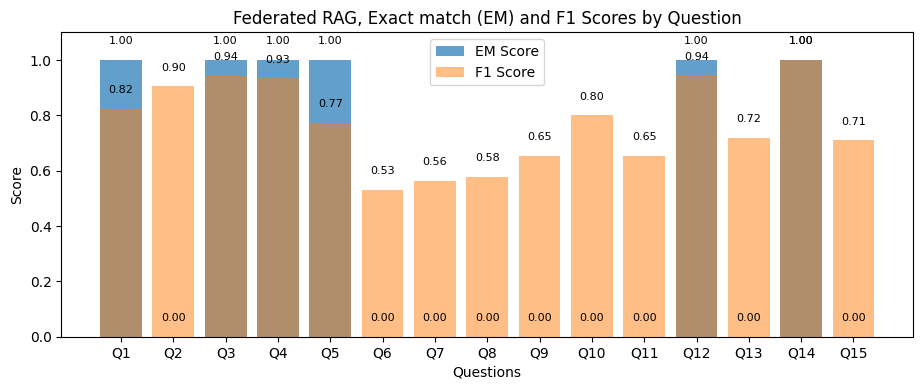

In [ ]:
# Visualize results2
plt.figure(figsize=(18, 4))

# Plot individual scores
plt.subplot(1, 2, 1)
question_ids = [f"Q{i+1}" for i in range(len(em_scores))]
bars1 = plt.bar(question_ids, em_scores, alpha=0.7, label='EM Score')
bars2 = plt.bar(question_ids, f1_scores, alpha=0.5, label='F1 Score')
plt.ylim(0, 1.1)
plt.xlabel('Questions')
plt.ylabel('Score')
plt.title('Federated RAG, Exact match (EM) and F1 Scores by Question')
plt.legend()

# Add score values above each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.05,
                                 f'{height:.2f}', ha='center', va='bottom', fontsize=8)


plt.tight_layout()
plt.savefig('Federated_RAG_em_f1_by_question.jpg', format='jpg', dpi=300) # Save as JPEG
plt.show()

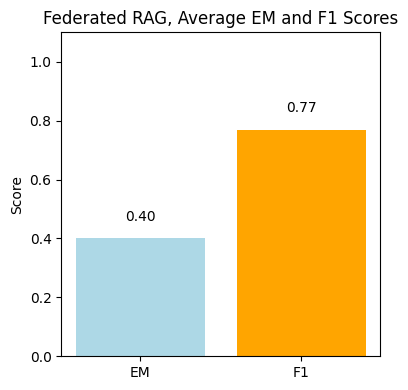

In [ ]:
#Plot average EM & F1 in a separate square figure
plt.figure(figsize=(4, 4))
bars3 = plt.bar(['EM', 'F1'], [avg_em, avg_f1], color=['lightblue', 'orange'])
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Federated RAG, Average EM and F1 Scores')
for bar in bars3:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + .05, f'{h:.2f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig('Federated_RAG_em_f1_average.jpg', format='jpg', dpi=300) # Save as JPEG
plt.show()

In [ ]:
%%writefile requirements.txt
streamlit
openai
langchain
langchain-core
langchain-openai
langchain-community
faiss-cpu
python-dotenv
beautifulsoup4
requests
sentence-transformers

Writing requirements.txt


In [ ]:
%%writefile Federated_RAG_ChatBot.py

import streamlit as st
import os
import sys
from bs4 import BeautifulSoup
import string
import requests
from urllib.parse import urljoin, urlparse
import time  # For simulating progress

from langchain.text_splitter import CharacterTextSplitter
from langchain_community.vectorstores import FAISS  # Fixed import from community package
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain.docstore.document import Document
from langchain.chains import RetrievalQA
from langchain.retrievers import MergerRetriever

# Set page configuration
st.set_page_config(
    page_title="🐱 Federated RAG Chatbot", #Click Win + . to show icons
    page_icon="./icon.png",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Add custom CSS for enhanced styling
st.markdown("""
<style>
    .main-header {
        font-size: 2.5rem;
        color: #1E88E5;
        text-align: center;
        margin-bottom: 0.5rem;
    }
    .sub-header {
        font-size: 1.5rem;
        color: #424242;
        text-align: center;
        margin-bottom: 2rem;
    }
    .chat-container {
        background-color: #f8f9fa;
        padding: 1.5rem;
        border-radius: 1rem;
        margin: 1rem 0;
        border-left: 4px solid #1E88E5;
    }
    .question-text {
        font-weight: bold;
        color: #1565C0;
        margin-bottom: 0.5rem;
    }
    .answer-text {
        color: #2E7D32;
        line-height: 1.6;
        background-color: #E8F5E8;
        padding: 1rem;
        border-radius: 0.5rem;
        margin-top: 0.5rem;
    }
    .source-header {
        font-size: 1.2rem;
        font-weight: bold;
        color: #1E88E5;
        margin-top: 1rem;
    }
    .source-text {
        background-color: #f0f2f6;
        padding: 1rem;
        border-radius: 0.5rem;
        margin-bottom: 1rem;
    }
    .info-box {
        background-color: #FFF3E0;
        padding: 1rem;
        border-radius: 0.5rem;
        border-left: 4px solid #FF9800;
        margin: 1rem 0;
    }
    .stats-container {
        background-color: #F3E5F5;
        padding: 1rem;
        border-radius: 0.5rem;
        margin: 1rem 0;
    }
    .university-badge {
        display: inline-block;
        padding: 0.25rem 0.5rem;
        border-radius: 0.25rem;
        font-size: 0.8rem;
        font-weight: bold;
        margin-right: 0.5rem;
    }
    .hull-badge {
        background-color: #E3F2FD;
        color: #1565C0;
    }
    .keele-badge {
        background-color: #F3E5F5;
        color: #7B1FA2;
    }
</style>
""", unsafe_allow_html=True)

# Set OpenAI API key from Streamlit secrets or environment variable
def get_api_key():
    try:
        if 'OPENAI_API_KEY' in st.secrets:
            return st.secrets["OPENAI_API_KEY"]
    except:
        pass

    if 'OPENAI_API_KEY' in os.environ:
        return os.environ["OPENAI_API_KEY"]
    else:
        return st.sidebar.text_input("Enter your OpenAI API key:", type="password")

api_key = get_api_key()
if api_key:
    os.environ["OPENAI_API_KEY"] = api_key
else:
    st.warning("Please enter your OpenAI API key to continue.")
    st.stop()

# Helper functions for web scraping and document processing
def clean_html(raw_html: str) -> str:
    """
    Remove boilerplate HTML tags (script, style, nav, footer, header) and return clean text.
    """
    soup = BeautifulSoup(raw_html, "html.parser")
    for tag in soup(["script", "style", "nav", "footer", "header"]):
        tag.decompose()
    text = soup.get_text(separator="\n")
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    return "\n".join(lines)

def chunk_documents(docs, chunk_size=1100, chunk_overlap=200):
    """Split each LangChain Document into smaller chunks for embeddings."""
    splitter = CharacterTextSplitter(
        separator="\n",
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )
    chunks = []
    for doc in docs:
        # Split page_content into pieces
        pieces = splitter.split_text(doc.page_content)
        for piece in pieces:
            chunks.append(Document(page_content=piece, metadata=doc.metadata))
    return chunks

def scrape_website(url, max_depth=1):
    """Custom web scraper that supports recursive crawling with depth control."""
    visited = set()
    documents = []
    domain = urlparse(url).netloc

    def scrape(current_url, depth):
        if depth > max_depth or current_url in visited:
            return

        visited.add(current_url)
        st.sidebar.write(f"Scraping: {current_url}")

        try:
            # Use a realistic user agent
            headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
            response = requests.get(current_url, timeout=10, headers=headers)
            response.encoding = response.apparent_encoding  # Fix encoding issues
            response.raise_for_status()

            content = clean_html(response.text)  # Clean HTML

            # Create document with metadata
            doc = Document(
                page_content=content,
                metadata={"source": current_url, "title": current_url.split("/")[-1]}
            )
            documents.append(doc)

            # Only follow links if not at max depth
            if depth < max_depth:
                soup = BeautifulSoup(response.text, "html.parser")
                for link in soup.find_all("a", href=True):
                    href = link["href"]
                    full_url = urljoin(current_url, href)

                    # Only follow links within the same domain
                    if urlparse(full_url).netloc == domain and full_url not in visited:
                        scrape(full_url, depth + 1)

        except Exception as e:
            st.sidebar.write(f"Error scraping {current_url}: {str(e)}")

    # Start scraping from the initial URL
    scrape(url, 0)
    return documents

def get_federated_docs(urls, max_depth=1):
    """
    Crawl a list of URLs up to max_depth and return a list of LangChain Document objects.
    """
    all_docs = []
    for url in urls:
        docs = scrape_website(url, max_depth=max_depth)
        all_docs.extend(docs)
    return all_docs

# Initialize session state for storing indices
if 'initialized' not in st.session_state:
    st.session_state.initialized = False
    st.session_state.hull_index = None
    st.session_state.keele_index = None
    st.session_state.combined_retriever = None
    st.session_state.qa_chain = None
    st.session_state.chat_history = []

# Main function to build the Streamlit app
def main():
    # Header
    st.markdown("<h1 class='main-header'>🐱 Federated RAG Chatbot</h1>", unsafe_allow_html=True)
    st.markdown("<h3 style='text-align: center; color: #666;'>MSc Artificial Intelligence online at University of Hull &</h3>", unsafe_allow_html=True)
    st.markdown("<h3 style='text-align: center; color: #666;'>MSc Computer Science with Artificial Intelligence online at Keele University</h3>", unsafe_allow_html=True)

    # Sidebar for configuration
    st.sidebar.title("⚙️ Configuration")

    # Model settings (compact)
    with st.sidebar.expander("🐱 Model Settings", expanded=False):
        embeddings_model = st.selectbox(
            "Embeddings Model",
            ["text-embedding-3-small", "text-embedding-3-large"],
            index=0,
            help="Choose the OpenAI embedding model"
        )

        llm_model = st.selectbox(
            "LLM Model",
            ["gpt-4o", "gpt-3.5-turbo"],
            index=0,
            help="Choose the language model for generating responses"
        )

        temperature = st.slider(
            "Temperature",
            0.0, 1.0, 0.3, 0.1,
            help="Controls randomness in responses"
        )

    # Retrieval settings (compact)
    with st.sidebar.expander("🔍 Retrieval Settings", expanded=False):
        k_docs = st.slider(
            "Documents per source",
            3, 15, 5,
            help="How many relevant document chunks to retrieve from each university"
        )

    # University data sources (compact)
    with st.sidebar.expander("🏫 Data Sources", expanded=False):
        st.write("**University of Hull:**")
        st.write("• MSc Artificial Intelligence")
        st.write("• Course information & FAQs")
        st.write("• Funding & costs")

        st.write("**Keele University:**")
        st.write("• MSc Computer Science with AI")
        st.write("• Online study information")
        st.write("• Program details")

    # Define URLs for Hull and Keele
    hull_urls = [
        "https://online.hull.ac.uk",
        "https://online.hull.ac.uk/contact",
        "https://online.hull.ac.uk/why-join-us/faqs",
        "https://online.hull.ac.uk/funding-options",
        "https://online.hull.ac.uk/course-costs",
        "https://online.hull.ac.uk/courses/msc-artificial-intelligence"
    ]

    keele_urls = [
        "https://online.keele.ac.uk/online-programme/msc-computer-science-with-artificial-intelligence",
        "https://online.keele.ac.uk/online-study",
        "https://online.keele.ac.uk/about-us"
    ]

    # Initialize button at the top
    if not st.session_state.initialized:
        if st.sidebar.button("🚀 Initialize Federated RAG System", type="primary", use_container_width=True):
            with st.spinner("Initializing Federated RAG System..."):
                # Initialize embedding model
                embeddings = OpenAIEmbeddings(model=embeddings_model)

                # Progress bar for initialization
                progress_bar = st.progress(0)

                # Load, clean, and chunk documents for Hull
                st.sidebar.write("Loading Hull documents...")
                progress_bar.progress(10)
                hull_raw = get_federated_docs(hull_urls, max_depth=1)
                progress_bar.progress(30)
                hull_chunks = chunk_documents(hull_raw)
                st.sidebar.write(f"Created {len(hull_chunks)} Hull chunks.")
                progress_bar.progress(40)

                # Load, clean, and chunk documents for Keele
                st.sidebar.write("Loading Keele documents...")
                progress_bar.progress(50)
                keele_raw = get_federated_docs(keele_urls, max_depth=1)
                progress_bar.progress(70)
                keele_chunks = chunk_documents(keele_raw)
                st.sidebar.write(f"Created {len(keele_chunks)} Keele chunks.")
                progress_bar.progress(80)

                # Build FAISS indexes
                st.sidebar.write("Building FAISS indices...")
                hull_index = FAISS.from_documents(hull_chunks, embeddings)
                keele_index = FAISS.from_documents(keele_chunks, embeddings)
                progress_bar.progress(90)

                # Build retrievers
                hull_retriever = hull_index.as_retriever(search_kwargs={"k": k_docs})
                keele_retriever = keele_index.as_retriever(search_kwargs={"k": k_docs})

                # Composite retriever
                combined_retriever = MergerRetriever(retrievers=[hull_retriever, keele_retriever])

                # Build RetrievalQA chain
                qa_chain = RetrievalQA.from_chain_type(
                    llm=ChatOpenAI(model_name=llm_model, temperature=temperature),
                    retriever=combined_retriever,
                    return_source_documents=True,
                    chain_type="stuff",
                )

                # Store in session state
                st.session_state.hull_index = hull_index
                st.session_state.keele_index = keele_index
                st.session_state.combined_retriever = combined_retriever
                st.session_state.qa_chain = qa_chain
                st.session_state.initialized = True
                st.session_state.hull_chunks_count = len(hull_chunks)
                st.session_state.keele_chunks_count = len(keele_chunks)

                progress_bar.progress(100)
                st.sidebar.success("Initialization complete!")
                st.rerun()

        st.sidebar.info("👆 Click Initialize to start!")
    else:
        st.sidebar.success("✅ System Ready")
        if st.sidebar.button("🔄 Reset System", use_container_width=True):
            st.session_state.initialized = False
            st.session_state.hull_index = None
            st.session_state.keele_index = None
            st.session_state.combined_retriever = None
            st.session_state.qa_chain = None
            st.session_state.chat_history = []
            st.rerun()

    # System statistics (if initialized)
    if st.session_state.initialized:
        st.sidebar.divider()
        st.sidebar.subheader("📊 System Stats")
        col1, col2 = st.sidebar.columns(2)
        with col1:
            st.metric("Hull Chunks", st.session_state.get('hull_chunks_count', 'N/A'))
            st.metric("Questions", len(st.session_state.chat_history))
        with col2:
            st.metric("Keele Chunks", st.session_state.get('keele_chunks_count', 'N/A'))
            st.metric("LLM", llm_model.split('-')[0])

    # Main chat interface
    if st.session_state.initialized:
        # Information box
        st.markdown("""
        <div class='info-box'>
            <strong>ℹ️ How it works:</strong> This Federated RAG system combines information from multiple universities
            to provide comprehensive comparisons between Hull's MSc AI and Keele's MSc Computer Science with AI programs.
        </div>
        """, unsafe_allow_html=True)

        # Display chat history
        if st.session_state.chat_history:
            st.subheader("💬 Chat History")
            for i, (question, answer, sources) in enumerate(st.session_state.chat_history):
                with st.container():
                    st.markdown(f"""
                    <div class='chat-container'>
                        <div class='question-text'>Q{i+1}: {question}</div>
                        <div class='answer-text'><strong>AI:</strong> {answer}</div>
                    </div>
                    """, unsafe_allow_html=True)

                    with st.expander(f"📚 View Sources for Q{i+1} ({len(sources)} documents)"):
                        hull_sources = []
                        keele_sources = []

                        for source in sources:
                            if 'hull.ac.uk' in source.metadata.get('source', ''):
                                hull_sources.append(source)
                            elif 'keele.ac.uk' in source.metadata.get('source', ''):
                                keele_sources.append(source)

                        if hull_sources:
                            st.markdown("**🎓 University of Hull Sources:**")
                            for j, source in enumerate(hull_sources, 1):
                                st.markdown(f"<span class='university-badge hull-badge'>Hull {j}</span>", unsafe_allow_html=True)
                                st.markdown(f"**Source:** {source.metadata.get('source', 'Unknown')}")
                                st.markdown(f"<div class='source-text'>{source.page_content[:400]}...</div>", unsafe_allow_html=True)

                        if keele_sources:
                            st.markdown("**🎓 Keele University Sources:**")
                            for j, source in enumerate(keele_sources, 1):
                                st.markdown(f"<span class='university-badge keele-badge'>Keele {j}</span>", unsafe_allow_html=True)
                                st.markdown(f"**Source:** {source.metadata.get('source', 'Unknown')}")
                                st.markdown(f"<div class='source-text'>{source.page_content[:400]}...</div>", unsafe_allow_html=True)

                    st.markdown("---")

        # Question input section
        st.subheader("🤔 Ask a Question")

        # Create columns for better layout
        col1, col2 = st.columns([4, 1])

        with col1:
            user_question = st.text_input(
                "Compare programs or ask about Hull/Keele universities:",
                placeholder="e.g., How long does the MSc Artificial Intelligence course take to complete?",
                key="question_input"
            )

        with col2:
            st.write("")  # Add some spacing
            ask_button = st.button("🔍 Ask", type="primary", use_container_width=True)

        # Additional action buttons
        col3, col4, col5 = st.columns(3)
        with col3:
            clear_history = st.button("🗑️ Clear History", use_container_width=True)
        with col4:
            example_question = st.button("💡 Example Question", use_container_width=True)
        with col5:
            show_stats = st.button("📈 Show Statistics", use_container_width=True)

        # Handle button actions
        if example_question:
            st.session_state.example_question = "How long does the MSc Artificial Intelligence course take to complete?"
            st.rerun()

        if clear_history:
            st.session_state.chat_history = []
            st.rerun()

        if show_stats and st.session_state.chat_history:
            st.subheader("📊 Session Statistics")
            total_questions = len(st.session_state.chat_history)
            total_sources = sum(len(sources) for _, _, sources in st.session_state.chat_history)
            avg_sources = total_sources / total_questions if total_questions > 0 else 0

            # Count sources by university
            hull_source_count = 0
            keele_source_count = 0
            for _, _, sources in st.session_state.chat_history:
                for source in sources:
                    if 'hull.ac.uk' in source.metadata.get('source', ''):
                        hull_source_count += 1
                    elif 'keele.ac.uk' in source.metadata.get('source', ''):
                        keele_source_count += 1

            col_stat1, col_stat2, col_stat3, col_stat4 = st.columns(4)
            with col_stat1:
                st.metric("Total Questions", total_questions)
            with col_stat2:
                st.metric("Hull Sources Used", hull_source_count)
            with col_stat3:
                st.metric("Keele Sources Used", keele_source_count)
            with col_stat4:
                st.metric("Avg Sources/Question", f"{avg_sources:.1f}")

        # Use example question if set
        if hasattr(st.session_state, 'example_question'):
            user_question = st.session_state.example_question
            del st.session_state.example_question
            ask_button = True

        # Process question
        if ask_button and user_question:
            with st.spinner('🔍 Searching across universities and generating response...'):
                # Initialize progress bar
                progress_bar = st.progress(0)

                # Simulate progress for the query process
                for percent_complete in range(1, 51):
                    time.sleep(0.02)  # Simulate retrieval delay
                    progress_bar.progress(percent_complete)

                # Get response from QA chain
                response = st.session_state.qa_chain({"query": user_question})
                answer = response["result"]
                sources = response["source_documents"]

                # Continue progress simulation
                for percent_complete in range(51, 101):
                    time.sleep(0.01)  # Simulate processing delay
                    progress_bar.progress(percent_complete)

                # Add to chat history
                st.session_state.chat_history.append((user_question, answer, sources))

                # Show success message with source breakdown
                hull_count = sum(1 for s in sources if 'hull.ac.uk' in s.metadata.get('source', ''))
                keele_count = sum(1 for s in sources if 'keele.ac.uk' in s.metadata.get('source', ''))
                st.success(f"✅ Generated response using {len(sources)} sources ({hull_count} Hull, {keele_count} Keele)!")

                # Clear the input box and rerun to show the updated chat
                st.rerun()

        elif ask_button and not user_question:
            st.warning("⚠️ Please enter a question before asking!")

    else:
        # System not ready - show initialization prompt
        st.markdown("""
        <div class='info-box'>
            <strong>🚀 Getting Started:</strong><br>
            1. Configure your settings in the sidebar<br>
            2. Enter your OpenAI API key if required<br>
            3. Click "Initialize Federated RAG System" to load data from both universities<br>
            4. Start comparing Hull and Keele AI programs!
        </div>
        """, unsafe_allow_html=True)

        # Show sample questions
        st.subheader("💡 Sample Questions You Can Ask:")
        sample_questions = [
            "How long does the MSc Artificial Intelligence course take to complete?",
            "What is the total cost of the MSc Artificial Intelligence Online program?",
            "What is the minimum academic qualification required to apply for the MSc Artificial Intelligence (Online) program?",
            "What if I don't have a degree but have relevant professional experience?",
            "What language proficiency is required if my first language isn't English?"
        ]

        for i, question in enumerate(sample_questions, 1):
            st.write(f"{i}. {question}")

if __name__ == "__main__":
    main()

Overwriting Federated_RAG_ChatBot.py
